In [1]:
!pip install gurobipy


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\simor\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 2 – Model extensions on the 100 bricks / 10 SRs instance


### 2.1 100 bricks / 10 SRs – computing the non‑dominated set (integral assignments)

In this section we:
- load the 100×10 instance from the Excel file,
- rebuild the distance matrix and the current territories from the raw data,
- reuse the same workload‑balance constraints as in Step 1,
- compute the non‑dominated set for the bi‑objective problem  
  (minimize distance, minimize disruption) using an ε‑constraint scheme.


Total workload after scaling: 10.0000 (target = 10)
Office indices (0‑based): [2, 17, 29, 32, 58, 65, 72, 78, 81, 97]
Distance matrix shape (SRs × bricks): (10, 100)

=== 2.1 100 bricks / 10 SRs – integral assignments (x ∈ {0,1}) ===
Restricted license - for non-production use only - expires 2026-11-23
Disruption at minimal distance: 4.8015
Minimal achievable disruption: 0.3427
ε‑grid: [0.3427 0.7142 1.0858 1.4574 1.829  2.2005 2.5721 2.9437 3.3152 3.6868
 4.0584 4.4299 4.8015]
ε = 0.3427  →  distance = 27.379, disruption = 0.3427
ε = 0.7142  →  distance = 23.283, disruption = 0.7007
ε = 1.0858  →  distance = 21.396, disruption = 1.0810
ε = 1.4574  →  distance = 19.962, disruption = 1.4487
ε = 1.8290  →  distance = 18.745, disruption = 1.8028
ε = 2.2005  →  distance = 17.802, disruption = 2.1885
ε = 2.5721  →  distance = 17.069, disruption = 2.5644
ε = 2.9437  →  distance = 16.366, disruption = 2.9434
ε = 3.3152  →  distance = 15.812, disruption = 3.3139
ε = 3.6868  →  distance = 15.53

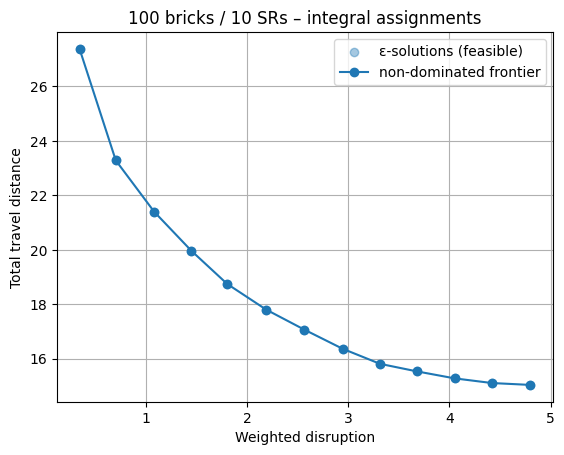

In [2]:

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from gurobipy import Model, GRB

# ---------------------------------------------------------------------------
# Data loading and preprocessing
# ---------------------------------------------------------------------------

CURRENT_DIR = Path.cwd()
DATA_PATH = CURRENT_DIR / "data-100x10.xlsx"

# The Excel file contains, for each brick:
#  - x, y       : geographical coordinates
#  - index      : workload index
#  - current    : id of the currently responsible SR
#  - office     : 1 if the brick hosts an SR office, 0 otherwise
df = pd.read_excel(
    DATA_PATH,
    header=None,
    usecols="A:E",
    nrows=100
)
df.columns = ["x", "y", "index", "current", "office"]

Bricks = len(df)

# Number of sales reps = number of offices in the file
Sales = int(df["office"].sum())

# Raw workload indices from the file
workloads_raw = df["index"].to_numpy(dtype=float)

# In the original 4×22 instance, the sum of the indices was equal to the
# number of SRs. We keep the same convention here by rescaling the indices
# so that the total workload equals the number of SRs.
scale = Sales / workloads_raw.sum()
workloads = workloads_raw * scale
print(f"Total workload after scaling: {workloads.sum():.4f} (target = {Sales})")

# Coordinates of all bricks
coords = df[["x", "y"]].to_numpy(dtype=float)

# Indices of bricks that host an SR office (0-based)
office_indices = df.index[df["office"] == 1].to_list()
assert len(office_indices) == Sales, "Office count must match the number of SRs"
print(f"Office indices (0‑based): {office_indices}")

# Distance[j, i] = distance between office of SR j and brick i.
# We build SR j in the same order as office_indices.
Distance = np.vstack([
    np.linalg.norm(coords - coords[office_idx], axis=1)
    for office_idx in office_indices
])
print("Distance matrix shape (SRs × bricks):", Distance.shape)

# Initial (current) assignment matrix:
#   SR_initial[j, i] = 1 if brick i currently belongs to SR j, 0 otherwise.
SR_initial = np.zeros((Sales, Bricks), dtype=int)
for i in range(Bricks):
    sr = int(df.loc[i, "current"]) - 1  # data is 1‑based
    if 0 <= sr < Sales:
        SR_initial[sr, i] = 1

# Workload bounds as in the project statement
WORKLOAD_BOUNDS = (0.8, 1.2)


# ---------------------------------------------------------------------------
# Model builder
# ---------------------------------------------------------------------------

def build_assignment_model(
    vtype=GRB.BINARY,
    workloads=workloads,
    distance=Distance,
    initial_assignment=SR_initial,
    workload_bounds=WORKLOAD_BOUNDS,
    model_name="Pfizer_100x10",
):
    """Build a Gurobi model for the assignment problem.

    Parameters
    ----------
    vtype : gurobipy constant
        GRB.BINARY (default) for integral assignments or GRB.CONTINUOUS
        for partial assignments.
    workloads : np.ndarray
        Workload index of each brick (length = number of bricks).
    distance : np.ndarray
        Matrix of shape (Sales, Bricks) with travel distances.
    initial_assignment : np.ndarray
        0/1 matrix of shape (Sales, Bricks) describing the current territories.
    workload_bounds : (float, float)
        Lower and upper bounds on each SR's workload.
    model_name : str
        Name of the Gurobi model.

    Returns
    -------
    m : gurobipy.Model
    x : gurobipy.tupledict
        Decision variables x[j, i] (fraction of brick i assigned to SR j).
    distance_expr : gurobipy.LinExpr
        Expression for the total traveled distance.
    disruption_expr : gurobipy.LinExpr
        Expression for the (workload‑weighted) disruption.
    """
    m = Model(model_name)
    m.Params.OutputFlag = 0  # keep the log clean

    sales, bricks = distance.shape

    # x[j, i] is the fraction of brick i served by SR j.
    x = m.addVars(sales, bricks, vtype=vtype, name="x")

    # (1) Coverage: each brick must be entirely covered
    for i in range(bricks):
        m.addConstr(sum(x[j, i] for j in range(sales)) == 1.0, name=f"assign_{i}")

    # (2) Workload balance: each SR workload in [min_w, max_w]
    min_w, max_w = workload_bounds
    for j in range(sales):
        load = sum(x[j, i] * workloads[i] for i in range(bricks))
        m.addConstr(load >= min_w, name=f"load_min_{j}")
        m.addConstr(load <= max_w, name=f"load_max_{j}")

    # (3) Total distance
    distance_expr = sum(
        distance[j, i] * x[j, i] for j in range(sales) for i in range(bricks)
    )

    # (4) Disruption, weighted by workload:
    #     if a brick changes SR, we incur its workload as disruption.
    disruption_expr = sum(
        0.5
        * (initial_assignment[j, i] - 2 * initial_assignment[j, i] * x[j, i] + x[j, i])
        * workloads[i]
        for j in range(sales)
        for i in range(bricks)
    )

    return m, x, distance_expr, disruption_expr


# ---------------------------------------------------------------------------
# ε‑constraint scheme (distance as main objective, disruption constrained)
# ---------------------------------------------------------------------------

def epsilon_pareto(vtype=GRB.BINARY, grid_size=13):
    """Compute Pareto points with an ε‑constraint on the disruption.

    The function returns a list of (disruption, distance) points.
    """
    # 1) Distance‑only solution
    m_dist, _, dist_expr_dist, disr_expr_dist = build_assignment_model(vtype=vtype)
    m_dist.setObjective(dist_expr_dist, GRB.MINIMIZE)
    m_dist.optimize()
    if m_dist.status != GRB.OPTIMAL:
        raise RuntimeError("Distance‑only model is infeasible.")
    disr_at_min_dist = disr_expr_dist.getValue()
    print(f"Disruption at minimal distance: {disr_at_min_dist:.4f}")

    # 2) Disruption‑only solution
    m_disr, _, _, disr_expr_disr = build_assignment_model(vtype=vtype)
    m_disr.setObjective(disr_expr_disr, GRB.MINIMIZE)
    m_disr.optimize()
    if m_disr.status != GRB.OPTIMAL:
        raise RuntimeError("Disruption‑only model is infeasible.")
    disr_min = disr_expr_disr.getValue()
    print(f"Minimal achievable disruption: {disr_min:.4f}")

    lo, hi = sorted((disr_min, disr_at_min_dist))
    epsilons = np.linspace(lo, hi, grid_size)
    print("ε‑grid:", np.round(epsilons, 4))

    pareto = []
    for eps in epsilons:
        m, _, dist_expr, disr_expr = build_assignment_model(vtype=vtype)
        # ε‑constraint on disruption
        m.addConstr(disr_expr <= float(eps) + 1e-6, name="eps_disruption")
        m.setObjective(dist_expr, GRB.MINIMIZE)
        m.optimize()

        if m.status == GRB.OPTIMAL:
            d = dist_expr.getValue()
            r = disr_expr.getValue()
            pareto.append((r, d))
            print(f"ε = {eps:.4f}  →  distance = {d:.3f}, disruption = {r:.4f}")
        else:
            print(f"ε = {eps:.4f}  →  infeasible")

    return pareto


def non_dominated(points, tol=1e-6):
    """Extract non‑dominated points from a list of (disruption, distance)."""
    pts = sorted(points, key=lambda p: (p[0], p[1]))  # sort by disruption then distance
    nd = []
    best_dist = float("inf")
    for disr, dist in pts:
        if dist < best_dist - tol:
            nd.append((disr, dist))
            best_dist = dist
    return nd


# ---------------------------------------------------------------------------
# 2.1 – 100 bricks / 10 SRs with integral assignments
# ---------------------------------------------------------------------------

print("\n=== 2.1 100 bricks / 10 SRs – integral assignments (x ∈ {0,1}) ===")
pareto_int = epsilon_pareto(vtype=GRB.BINARY, grid_size=13)
nd_int = non_dominated(pareto_int)

if nd_int:
    disr_all, dist_all = zip(*pareto_int)
    disr_nd, dist_nd = zip(*nd_int)

    plt.figure()
    plt.scatter(disr_all, dist_all, alpha=0.4, label="ε‑solutions (feasible)")
    plt.plot(disr_nd, dist_nd, "o-", label="non‑dominated frontier")
    plt.xlabel("Weighted disruption")
    plt.ylabel("Total travel distance")
    plt.title("100 bricks / 10 SRs – integral assignments")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No Pareto points found for the integral model.")



### 2.2 Allowing partial assignment of bricks

We now relax the integrality constraints and allow each brick to be **split between several SRs**
(i.e., the variables become continuous in \([0,1]\)).  
The model is exactly the same as above; only the variable type changes.
We then compare the Pareto front with the integral case.



=== 2.2 100 bricks / 10 SRs – partial assignments allowed (x ∈ [0,1]) ===
Disruption at minimal distance: 5.0104
Minimal achievable disruption: 0.3426
ε‑grid: [0.3426 0.7316 1.1206 1.5096 1.8986 2.2875 2.6765 3.0655 3.4545 3.8435
 4.2324 4.6214 5.0104]
ε = 0.3426  →  distance = 26.645, disruption = 0.3426
ε = 0.7316  →  distance = 22.958, disruption = 0.7316
ε = 1.1206  →  distance = 21.171, disruption = 1.1206
ε = 1.5096  →  distance = 19.640, disruption = 1.5096
ε = 1.8986  →  distance = 18.410, disruption = 1.8986
ε = 2.2875  →  distance = 17.509, disruption = 2.2875
ε = 2.6765  →  distance = 16.734, disruption = 2.6765
ε = 3.0655  →  distance = 16.079, disruption = 3.0655
ε = 3.4545  →  distance = 15.636, disruption = 3.4545
ε = 3.8435  →  distance = 15.296, disruption = 3.8435
ε = 4.2324  →  distance = 15.098, disruption = 4.2324
ε = 4.6214  →  distance = 14.982, disruption = 4.6214
ε = 5.0104  →  distance = 14.937, disruption = 5.0104


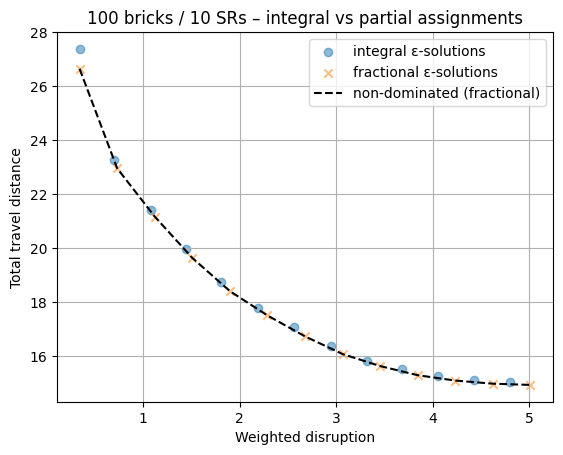

Minimal distance (integral model) : 15.037
Minimal distance (fractional model): 14.937


In [3]:

import matplotlib.pyplot as plt
from gurobipy import GRB

print("\n=== 2.2 100 bricks / 10 SRs – partial assignments allowed (x ∈ [0,1]) ===")

# Compute Pareto set with continuous variables
pareto_frac = epsilon_pareto(vtype=GRB.CONTINUOUS, grid_size=13)
nd_frac = non_dominated(pareto_frac)

if pareto_frac and 'pareto_int' in globals():
    # Plot both sets on the same figure for an easy visual comparison
    disr_int, dist_int = zip(*pareto_int)
    disr_frac, dist_frac = zip(*pareto_frac)

    plt.figure()
    plt.scatter(disr_int, dist_int, alpha=0.5, label="integral ε‑solutions")
    plt.scatter(disr_frac, dist_frac, alpha=0.5, marker="x", label="fractional ε‑solutions")

    if nd_frac:
        disr_nd_f, dist_nd_f = zip(*nd_frac)
        plt.plot(disr_nd_f, dist_nd_f, "k--", label="non‑dominated (fractional)")

    plt.xlabel("Weighted disruption")
    plt.ylabel("Total travel distance")
    plt.title("100 bricks / 10 SRs – integral vs partial assignments")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Simple numeric comparison: best distance for low disruption levels
    best_int = min(dist_int)
    best_frac = min(dist_frac)
    print(f"Minimal distance (integral model) : {best_int:.3f}")
    print(f"Minimal distance (fractional model): {best_frac:.3f}")
else:
    print("Could not compute Pareto points for the fractional model.")



> **Remark.**  
> The continuous model is mainly a *theoretical* extension: in practice a brick is typically
> assigned to a single SR.  
> However, relaxing integrality is very helpful to understand the structure of the problem
> and to measure the gap between the fully integral solution and the (optimistic) case where
> bricks can be fractionally shared between several SRs.



### 2.3 Adding a new SR when demand increases by 25 %

We now suppose that the demand (workload index) in **all bricks increases by 25 %**.  
To cope with this extra workload, Pfizer decides to hire **one additional sales representative**.

We keep the same structure of the model, but:
- workloads are multiplied by 1.25,
- we add a new SR with its own office,
- and we search for the *best brick* where this new office should be located,
  assuming it must coincide with one of the existing bricks.

For each candidate brick used as a potential office location, we:
1. build a new distance matrix with one additional SR row,
2. solve the distance‑minimization problem (with workload‑balance and disruption),
3. keep the best candidate according to the total distance (and report the disruption).


In [4]:

import numpy as np
from gurobipy import GRB

print("\n=== 2.3 Adding a new SR after a +25% demand increase ===")

# 1) Increase the workload uniformly by +25%
demand_factor = 1.25
workloads_plus = workloads * demand_factor
print(f"Total workload after +25% demand: {workloads_plus.sum():.3f}")

# Number of SRs with the new hire
Sales_new = Sales + 1

def build_distance_with_new_office(candidate_idx: int):
    """Create a distance matrix with one extra SR located at brick `candidate_idx`."""
    # distance from candidate office to all bricks
    new_row = np.linalg.norm(coords - coords[candidate_idx], axis=1)
    return np.vstack([Distance, new_row])

def evaluate_new_office(candidate_idx: int):
    """Solve the distance‑minimization model for a given office location.

    Returns
    -------
    (distance, disruption) if a feasible solution is found,
    (np.inf, np.inf) otherwise.
    """
    distance_new = build_distance_with_new_office(candidate_idx)

    # Extend the initial assignment matrix by a row of zeros for the new SR
    initial_new = np.vstack([SR_initial, np.zeros(Bricks, dtype=int)])

    m, _, dist_expr, disr_expr = build_assignment_model(
        vtype=GRB.BINARY,
        workloads=workloads_plus,
        distance=distance_new,
        initial_assignment=initial_new,
        workload_bounds=WORKLOAD_BOUNDS,
        model_name=f"Pfizer_100x10_plus1_office_{candidate_idx+1}",
    )
    m.setObjective(dist_expr, GRB.MINIMIZE)
    m.optimize()

    if m.status == GRB.OPTIMAL:
        return dist_expr.getValue(), disr_expr.getValue()
    else:
        return np.inf, np.inf

# 2) Enumerate all possible office locations and keep the best one for distance
best_idx = None
best_dist = float("inf")
best_disr = None

for candidate in range(Bricks):
    dist_val, disr_val = evaluate_new_office(candidate)
    if dist_val < best_dist:
        best_dist = dist_val
        best_disr = disr_val
        best_idx = candidate

if best_idx is not None and np.isfinite(best_dist):
    print(f"Best location for the new SR office: brick {best_idx + 1}")
    print(f"  → minimal total distance : {best_dist:.3f}")
    print(f"  → associated disruption  : {best_disr:.3f}")
else:
    print("No feasible location found for the new SR office.")



=== 2.3 Adding a new SR after a +25% demand increase ===
Total workload after +25% demand: 12.500
Best location for the new SR office: brick 35
  → minimal total distance : 14.125
  → associated disruption  : 6.595
